# 03Z: Method Comparison Summary (A-F)

## Objective
Build a central comparison notebook for clustering methods 03A-03F to identify useful evaluation and finance insights.

## Methods Compared
- 03A: K-Means
- 03B: Hierarchical
- 03C: DBSCAN
- 03D: GMM
- 03E: Autoencoder + K-Means
- 03F: t-SNE + K-Means

In [2]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

Note: you may need to restart the kernel to use updated packages.


In [3]:
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

feature_cache = DATA_DIR / 'clustering_features_latest.csv'
feature_df = pd.read_csv(feature_cache)

feature_cols = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]

X = feature_df[['Name'] + feature_cols].copy()
X[feature_cols] = X[feature_cols].replace([np.inf, -np.inf], np.nan)
X[feature_cols] = X[feature_cols].fillna(X[feature_cols].median(numeric_only=True))

print(f'Data dir: {DATA_DIR}')
print(f'Rows in feature cache: {len(X)}')

Data dir: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data
Rows in feature cache: 505


In [4]:
methods = {
    '03A': 'K-Means',
    '03B': 'Hierarchical',
    '03C': 'DBSCAN',
    '03D': 'GMM',
    '03E': 'Autoencoder + K-Means',
    '03F': 't-SNE + K-Means'
}

assignment_tables = {}
for m in methods:
    p = DATA_DIR / f'{m}_stock_cluster_assignments.csv'
    if not p.exists():
        raise FileNotFoundError(f'Missing assignment file: {p.name}')
    assignment_tables[m] = pd.read_csv(p)

print('Loaded assignment files:')
for m, df in assignment_tables.items():
    print(f'- {m}: {len(df)} rows | columns={list(df.columns)}')

Loaded assignment files:
- 03A: 505 rows | columns=['Name', 'cluster', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio']
- 03B: 505 rows | columns=['Name', 'cluster', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio']
- 03C: 505 rows | columns=['Name', 'cluster', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio']
- 03D: 505 rows | columns=['Name', 'cluster', 'cluster_confidence', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio']
- 03E: 505 rows | columns=['Name', 'cluster', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_

In [5]:
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - lo) / (hi - lo)

rows = []
cluster_profiles = {}

for method_id, method_name in methods.items():
    assign = assignment_tables[method_id].copy()

    # Keep one row per stock if duplicates exist
    assign = assign.drop_duplicates(subset=['Name'], keep='last')

    merged = X.merge(assign[['Name', 'cluster'] + ([c for c in ['cluster_confidence'] if c in assign.columns])], on='Name', how='inner')
    labels_all = merged['cluster'].astype(int)

    is_noise = labels_all == -1
    noise_ratio = float(is_noise.mean())

    core = merged.loc[~is_noise].copy() if is_noise.any() else merged.copy()
    core_labels = core['cluster'].astype(int)

    n_total = int(len(merged))
    n_core = int(len(core))
    n_clusters = int(core_labels.nunique()) if n_core > 0 else 0

    size_tbl = core_labels.value_counts().sort_index() if n_core > 0 else pd.Series(dtype=float)
    shares = (size_tbl / n_core) if n_core > 0 else pd.Series(dtype=float)

    max_share = float(shares.max()) if len(shares) else np.nan
    min_share = float(shares.min()) if len(shares) else np.nan
    effective_k = float(1 / np.sum(np.square(shares))) if len(shares) else np.nan

    profile_mean = core.groupby('cluster')[feature_cols].mean() if n_core > 0 else pd.DataFrame(columns=feature_cols)
    cluster_profiles[method_id] = profile_mean

    if len(profile_mean):
        risk_view = profile_mean[['avg_return', 'volatility', 'momentum', 'price_range']].copy()
        risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)
        best_rr = float(risk_view['return_to_risk'].max())
        best_rr_cluster = str(risk_view['return_to_risk'].idxmax())
        defensive_vol = float(risk_view['volatility'].min())
        defensive_cluster = str(risk_view['volatility'].idxmin())
        spread_return = float(profile_mean['avg_return'].std(ddof=0))
        spread_vol = float(profile_mean['volatility'].std(ddof=0))
        spread_momentum = float(profile_mean['momentum'].std(ddof=0))
        z = (profile_mean - profile_mean.mean()) / profile_mean.std(ddof=0).replace(0, np.nan)
        feature_separation = float(z.abs().mean().mean())
    else:
        best_rr = np.nan
        best_rr_cluster = ''
        defensive_vol = np.nan
        defensive_cluster = ''
        spread_return = np.nan
        spread_vol = np.nan
        spread_momentum = np.nan
        feature_separation = np.nan

    # Fair comparison metric: evaluate labels on original standardized feature space
    if n_clusters >= 2 and n_core > n_clusters:
        X_core = core[feature_cols].copy()
        X_core_scaled = StandardScaler().fit_transform(X_core)
        sil = float(silhouette_score(X_core_scaled, core_labels))
        dbi = float(davies_bouldin_score(X_core_scaled, core_labels))
    else:
        sil = np.nan
        dbi = np.nan

    confidence = float(core['cluster_confidence'].mean()) if 'cluster_confidence' in core.columns else np.nan

    rows.append({
        'method_id': method_id,
        'method_name': method_name,
        'n_total': n_total,
        'n_core': n_core,
        'n_clusters_core': n_clusters,
        'noise_ratio': noise_ratio,
        'max_cluster_share': max_share,
        'min_cluster_share': min_share,
        'effective_clusters': effective_k,
        'silhouette_original': sil,
        'dbi_original': dbi,
        'best_return_to_risk': best_rr,
        'best_rr_cluster': best_rr_cluster,
        'defensive_volatility': defensive_vol,
        'defensive_cluster': defensive_cluster,
        'spread_avg_return': spread_return,
        'spread_volatility': spread_vol,
        'spread_momentum': spread_momentum,
        'feature_separation_score': feature_separation,
        'avg_cluster_confidence': confidence
    })

comparison_df = pd.DataFrame(rows).sort_values('method_id').reset_index(drop=True)
comparison_df

,method_id,method_name,n_total,n_core,n_clusters_core,noise_ratio,max_cluster_share,min_cluster_share,effective_clusters,silhouette_original,dbi_original,best_return_to_risk,best_rr_cluster,defensive_volatility,defensive_cluster,spread_avg_return,spread_volatility,spread_momentum,feature_separation_score,avg_cluster_confidence
0,03A,K-Means,505,505,6,0.000000,0.566337,0.001980,2.401569,0.249622,0.978214,0.098866,1,0.015389,0,0.005949,0.005567,0.105761,0.766417,NaN
1,03B,Hierarchical,505,505,4,0.000000,0.548515,0.057426,2.545592,0.196511,1.747662,0.095585,0,0.015640,3,0.002334,0.002874,0.045618,0.808544,NaN
2,03C,DBSCAN,505,458,2,0.093069,0.989083,0.010917,1.022072,0.565218,0.552344,-0.009766,1,0.017093,0,0.000750,0.000731,0.013865,1.000000,NaN
3,03D,GMM,505,505,9,0.000000,0.348515,0.001980,4.794514,0.057459,1.611267,0.158062,7,0.015660,6,0.005700,0.006223,0.102969,0.729724,0.975309
4,03E,Autoencoder + K-Means,505,505,4,0.000000,0.596040,0.005941,2.280613,0.224873,1.546127,0.095246,0,0.016181,3,0.004995,0.004249,0.091611,0.850901,NaN
5,03F,t-SNE + K-Means,505,505,2,0.000000,0.534653,0.465347,1.990439,0.188030,1.984907,0.042271,0,0.017028,1,0.002189,0.001285,0.042306,1.000000,NaN


In [6]:
score_df = comparison_df.copy()

score_df['score_sil'] = minmax(score_df['silhouette_original'])
score_df['score_dbi'] = 1 - minmax(score_df['dbi_original'])
score_df['score_balance'] = 1 - minmax(score_df['max_cluster_share'])
score_df['score_rr'] = minmax(score_df['best_return_to_risk'])
score_df['score_noise'] = 1 - minmax(score_df['noise_ratio'])
score_df['score_sep'] = minmax(score_df['feature_separation_score'])

# Weighted final score focused on finance use-case and cluster quality
score_df['final_score'] = (
    0.25 * score_df['score_sil'] +
    0.20 * score_df['score_dbi'] +
    0.15 * score_df['score_balance'] +
    0.20 * score_df['score_rr'] +
    0.10 * score_df['score_noise'] +
    0.10 * score_df['score_sep']
)

ranking_df = score_df.sort_values('final_score', ascending=False).reset_index(drop=True)
ranking_df[['method_id', 'method_name', 'final_score', 'silhouette_original', 'dbi_original', 'best_return_to_risk', 'noise_ratio', 'max_cluster_share', 'feature_separation_score']]

,method_id,method_name,final_score,silhouette_original,dbi_original,best_return_to_risk,noise_ratio,max_cluster_share,feature_separation_score
0,03A,K-Means,0.577183,0.249622,0.978214,0.098866,0.000000,0.566337,0.766417
1,03C,DBSCAN,0.550000,0.565218,0.552344,-0.009766,0.093069,0.989083,1.000000
2,03E,Autoencoder + K-Means,0.505701,0.224873,1.546127,0.095246,0.000000,0.596040,0.850901
3,03D,GMM,0.502164,0.057459,1.611267,0.158062,0.000000,0.348515,0.729724
4,03B,Hierarchical,0.459461,0.196511,1.747662,0.095585,0.000000,0.548515,0.808544
5,03F,t-SNE + K-Means,0.432713,0.188030,1.984907,0.042271,0.000000,0.534653,1.000000


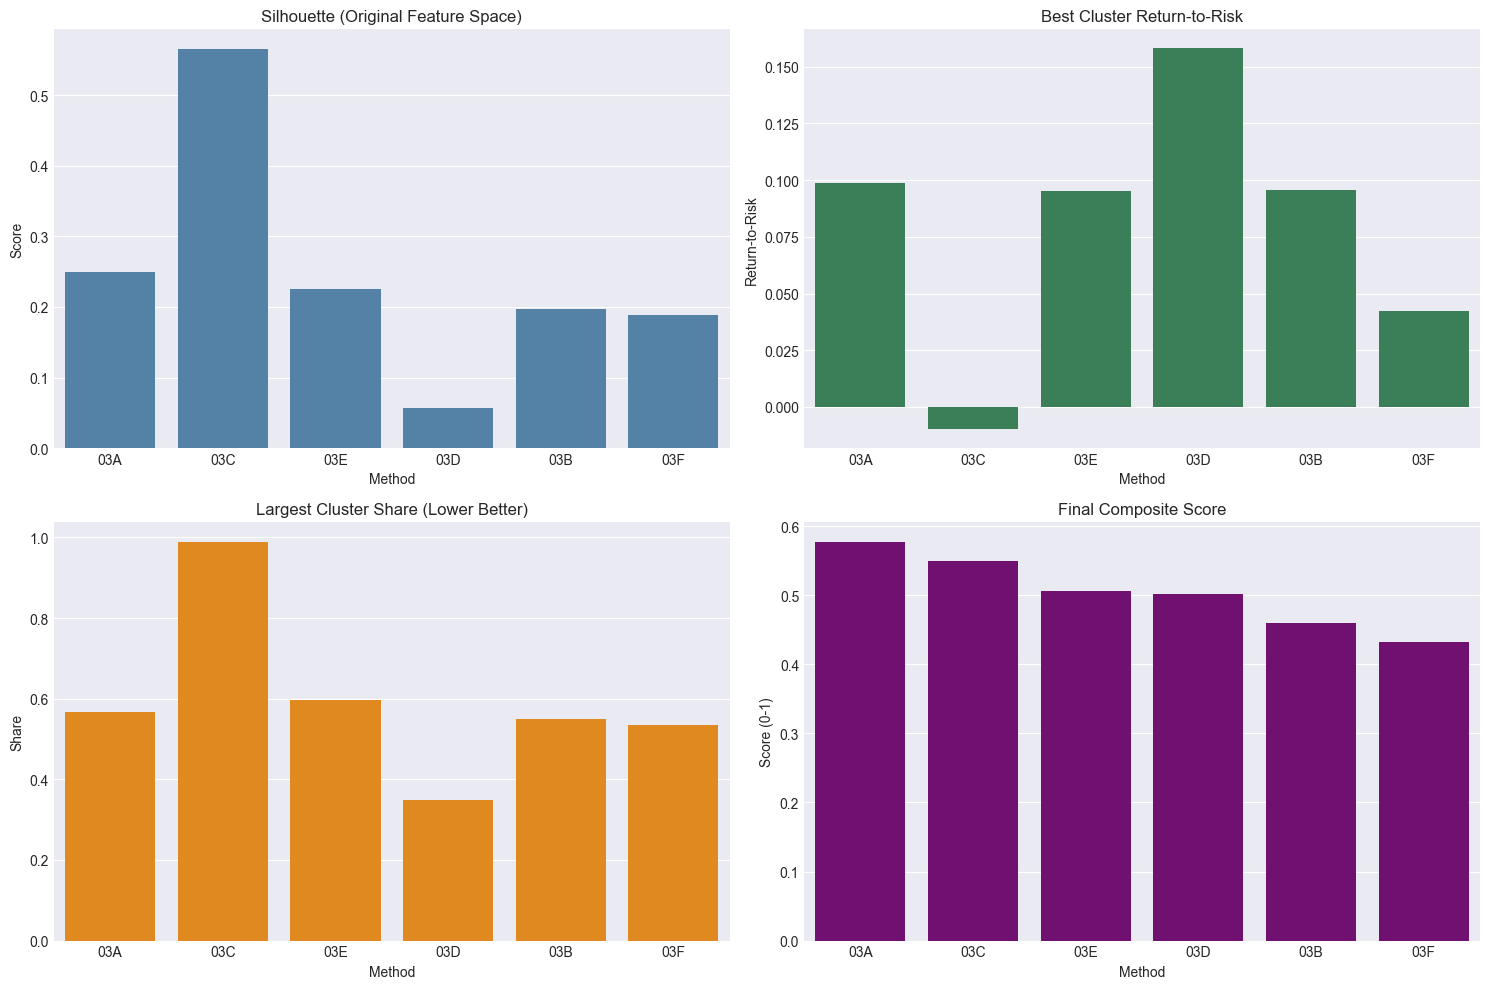

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=ranking_df, x='method_id', y='silhouette_original', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Silhouette (Original Feature Space)')
axes[0, 0].set_xlabel('Method')
axes[0, 0].set_ylabel('Score')

sns.barplot(data=ranking_df, x='method_id', y='best_return_to_risk', ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Best Cluster Return-to-Risk')
axes[0, 1].set_xlabel('Method')
axes[0, 1].set_ylabel('Return-to-Risk')

sns.barplot(data=ranking_df, x='method_id', y='max_cluster_share', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Largest Cluster Share (Lower Better)')
axes[1, 0].set_xlabel('Method')
axes[1, 0].set_ylabel('Share')

sns.barplot(data=ranking_df, x='method_id', y='final_score', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Final Composite Score')
axes[1, 1].set_xlabel('Method')
axes[1, 1].set_ylabel('Score (0-1)')

plt.tight_layout()
plt.savefig(GRAPH_DIR / '03Z_01_method_comparison_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
best_structure = ranking_df.loc[ranking_df['silhouette_original'].idxmax(), ['method_id', 'method_name']]
best_finance = ranking_df.loc[ranking_df['best_return_to_risk'].idxmax(), ['method_id', 'method_name']]
best_balance = ranking_df.loc[ranking_df['max_cluster_share'].idxmin(), ['method_id', 'method_name']]
best_defensive = ranking_df.loc[ranking_df['defensive_volatility'].idxmin(), ['method_id', 'method_name']]

print('=== Key Findings ===')
print(f"Best structural separation (silhouette): {best_structure['method_id']} - {best_structure['method_name']}")
print(f"Best finance upside proxy (return-to-risk): {best_finance['method_id']} - {best_finance['method_name']}")
print(f"Best cluster balance (lowest max share): {best_balance['method_id']} - {best_balance['method_name']}")
print(f"Most defensive cluster profile (lowest defensive volatility): {best_defensive['method_id']} - {best_defensive['method_name']}")

print('\nInterpretation tips:')
print('- If one method ranks high on silhouette but poor on balance, it may over-segment a niche style.')
print('- High return-to-risk with extreme concentration should be treated as tactical, not strategic allocation.')
print('- DBSCAN noise ratio is informative for anomaly detection and risk screening.')

=== Key Findings ===
Best structural separation (silhouette): 03C - DBSCAN
Best finance upside proxy (return-to-risk): 03D - GMM
Best cluster balance (lowest max share): 03D - GMM
Most defensive cluster profile (lowest defensive volatility): 03A - K-Means

Interpretation tips:
- If one method ranks high on silhouette but poor on balance, it may over-segment a niche style.
- High return-to-risk with extreme concentration should be treated as tactical, not strategic allocation.
- DBSCAN noise ratio is informative for anomaly detection and risk screening.


In [9]:
comparison_path = DATA_DIR / '03Z_method_comparison_summary.csv'
ranking_path = DATA_DIR / '03Z_method_comparison_ranking.csv'

comparison_df.to_csv(comparison_path, index=False)
ranking_df.to_csv(ranking_path, index=False)

print(f'Saved: {comparison_path}')
print(f'Saved: {ranking_path}')

Saved: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data\03Z_method_comparison_summary.csv
Saved: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data\03Z_method_comparison_ranking.csv


## Practical Finance Use
1. Use the top 1-2 methods by `final_score` as primary regime detectors.
2. Use DBSCAN in parallel as an outlier/noise risk monitor.
3. Build portfolio sleeves by cluster style: defensive, balanced, aggressive.
4. Re-run this notebook periodically to monitor drift in cluster structure and risk-return geometry.